In [ ]:
!pip install -q -U sentence-transformers faiss-cpu

In [ ]:
import os
import time
import re
import random
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import faiss
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from google.genai import types

In [ ]:
# ---------------------------------------------------------
# 1. Gemini client setup
# ---------------------------------------------------------
api_key = "YOUR_API_KEY" # replace with your own key
client = genai.Client(api_key=api_key)
print("Gemini client ready.")


✅ کلاینت جمینای آماده است.


In [ ]:
# 2. XML file reader
def parse_semeval_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    parsed_data = []
    for review in root.findall('Review'):
        for sentences in review.findall('sentences'):
            for sentence in sentences.findall('sentence'):
                text = sentence.find('text').text
                opinions = sentence.find('Opinions')
                if opinions is not None:
                    for opinion in opinions.findall('Opinion'):
                        target = opinion.get('target')
                        category = opinion.get('category')
                        polarity = opinion.get('polarity')
                        if polarity in ['positive', 'negative', 'neutral']:
                            parsed_data.append({
                                'text': text,
                                'target': target if target != 'NULL' else '',
                                'category': category,
                                'polarity': polarity
                            })
    return pd.DataFrame(parsed_data)

# load dataset
xml_file_name = 'ABSA16_Restaurants_Train_SB1_v2.xml'
df = parse_semeval_xml(xml_file_name)
print(f"Loaded XML — {len(df)} examples")

# split training corpus for RAG
train_corpus = df.iloc[:100].to_dict('records')
corpus_sentences = [record['text'] for record in train_corpus]

✅ فایل XML خوانده شد. تعداد کل نمونه‌ها: 2507


In [ ]:
print("Loading embedder and building FAISS index...")
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
corpus_embeddings = embedding_model.encode(corpus_sentences, normalize_embeddings=True)
dimension = corpus_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(corpus_embeddings)
print("FAISS index ready.")

⏳ در حال بارگذاری مدل امبدینگ و ساخت دیتابیس برداری FAISS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ بانک اطلاعاتی برداری FAISS با موفقیت ساخته شد.


In [ ]:
# 4. Core helpers and prompts
def retrieve_top_k_faiss(query_text, corpus_data, top_k=3):
    query_emb = embedding_model.encode([query_text], normalize_embeddings=True)
    distances, indices = faiss_index.search(query_emb, top_k)
    return [corpus_data[idx] for idx in indices[0]]

def parse_sentiment(raw_output):
    if not raw_output: return 'neutral'
    text = raw_output.lower().strip()
    match = re.search(r'\[(positive|negative|neutral)\]', text)
    if match: return match.group(1)
    pos_idx, neg_idx, neu_idx = text.rfind('positive'), text.rfind('negative'), text.rfind('neutral')
    max_idx = max(pos_idx, neg_idx, neu_idx)
    if max_idx == -1: return 'neutral'
    elif max_idx == pos_idx: return 'positive'
    elif max_idx == neg_idx: return 'negative'
    else: return 'neutral'

def get_zero_shot_prompt(text, aspect, category):
    return f"""Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.
Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.

Sentence: "{text}"
Target Aspect: "{aspect}"
Aspect Category: "{category}"

You MUST output your final sentiment label enclosed in brackets. Example: [positive], [negative], or [neutral]."""

def get_one_shot_prompt(text, aspect, category):
    return f"""Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.
Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.

Example:
Sentence: "The food was absolutely delicious, but the service was terrible."
Target Aspect: "food"
Aspect Category: "FOOD#QUALITY"
Sentiment: [positive]

Now classify the following:
Sentence: "{text}"
Target Aspect: "{aspect}"
Aspect Category: "{category}"
Sentiment:"""

def get_rag_prompt(text, aspect, category, retrieved_examples):
    prompt = f"""Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.
Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.

Here are some reference examples:\n"""
    for ex in retrieved_examples:
        prompt += f"""Sentence: "{ex['text']}" | Target Aspect: "{ex['target']}" | Aspect Category: "{ex['category']}" -> Sentiment: [{ex['polarity']}]\n"""

    prompt += f"""
Now classify the following:
Sentence: "{text}"
Target Aspect: "{aspect}"
Aspect Category: "{category}"

You MUST output your final sentiment label enclosed in brackets. Example: [positive], [negative], or [neutral].
Sentiment:"""
    return prompt


🚀 مرحله ۲: شروع ارزیابی روی ۵۰ نمونه تست...

⚡ در حال تست استراتژی: ZERO_SHOT
✅ [zero_shot] نمونه 1 | واقعی: negative -> پیش‌بینی: negative
✅ [zero_shot] نمونه 2 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 3 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 4 | واقعی: positive -> پیش‌بینی: neutral
✅ [zero_shot] نمونه 5 | واقعی: negative -> پیش‌بینی: negative
✅ [zero_shot] نمونه 6 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 7 | واقعی: negative -> پیش‌بینی: negative
✅ [zero_shot] نمونه 8 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 9 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 10 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 11 | واقعی: negative -> پیش‌بینی: negative
✅ [zero_shot] نمونه 12 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 13 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 14 | واقعی: positive -> پیش‌بینی: positive
✅ [zero_shot] نمونه 15 | واقعی: positive -> پیش‌ب

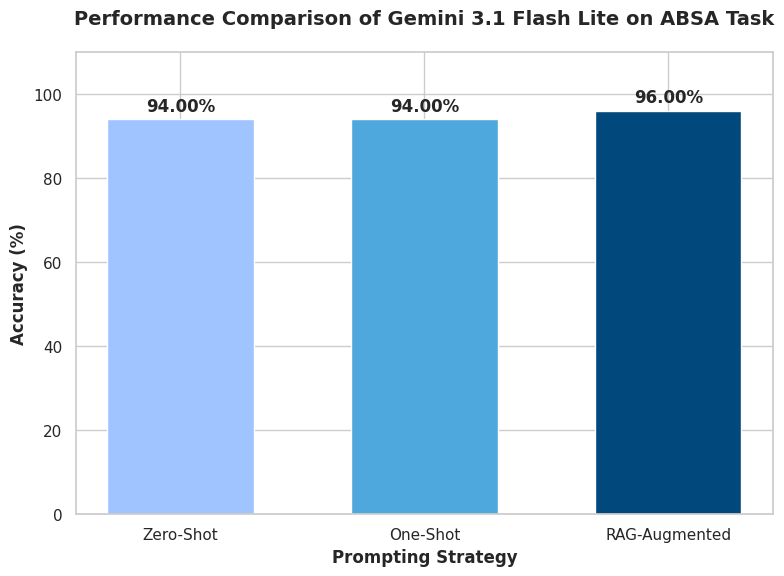

In [ ]:
def run_unified_absa(text, aspect, category, strategy, corpus_data=None, model_name='gemini-3.1-flash-lite'):
    if strategy == 'zero_shot':
        prompt = get_zero_shot_prompt(text, aspect, category)
    elif strategy == 'one_shot':
        prompt = get_one_shot_prompt(text, aspect, category)
    elif strategy == 'rag':
        retrieved_examples = retrieve_top_k_faiss(text, corpus_data, top_k=3)
        prompt = get_rag_prompt(text, aspect, category, retrieved_examples)

    generation_config = types.GenerateContentConfig(
        temperature=0.0,
        safety_settings=[
            types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_HATE_SPEECH, threshold=types.HarmBlockThreshold.BLOCK_NONE),
            types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_HARASSMENT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
            types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
            types.SafetySetting(category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT, threshold=types.HarmBlockThreshold.BLOCK_NONE),
        ]
    )

    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=generation_config
    )

    try:
        raw_text = response.text
    except:
        raw_text = ""

    final_label = parse_sentiment(raw_text)
    return final_label

# 5. Evaluation loop
print("\n" + "="*50)
print("Evaluating on 50 test samples...")
print("="*50)

test_indices = random.sample(range(100, len(df)), 50)
test_set = df.iloc[test_indices].to_dict('records')

strategies = ['zero_shot', 'one_shot', 'rag']
final_accuracies = {}

for strategy in strategies:
    print(f"\nStrategy: {strategy.upper()}")
    y_true = []
    y_pred = []

    for i, test_case in enumerate(test_set):
        true_label = test_case['polarity'].lower()

        try:
            predicted_label = run_unified_absa(
                text=test_case['text'],
                aspect=test_case['target'],
                category=test_case['category'],
                strategy=strategy,
                corpus_data=train_corpus,
                model_name='gemini-3.1-flash-lite'
            )

            y_true.append(true_label)
            y_pred.append(predicted_label)

            print(f"[{strategy}] sample {i+1} | gold: {true_label} -> pred: {predicted_label}")
            time.sleep(20) # 20s pause between API calls

        except Exception as e:
            print(f"Error on sample {i+1}: {e}")
            time.sleep(20)

    if len(y_true) > 0:
        acc = accuracy_score(y_true, y_pred) * 100
        final_accuracies[strategy] = acc
        print(f"{strategy} accuracy: {acc:.2f}%")

# 6. Plot results
print("\nPlotting comparison chart...")
methods = ['Zero-Shot', 'One-Shot', 'RAG-Augmented']
accuracies = [final_accuracies.get('zero_shot', 0), final_accuracies.get('one_shot', 0), final_accuracies.get('rag', 0)]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))
bars = plt.bar(methods, accuracies, color=['#A0C4FF', '#4EA8DE', '#01497C'], width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Performance Comparison of Gemini 3.1 Flash Lite on ABSA Task', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Prompting Strategy', fontsize=12, fontweight='bold')
plt.ylim(0, 110)
plt.savefig('Final_ABSA_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()